In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel("/content/Global_Superstore2.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

/tmp/ipykernel_1415/13081262.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [5]:
monthly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()

monthly_sales.head()

/tmp/ipykernel_1415/1794160230.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq="M")


,Order Date,Sales
0,2011-01-31,98898.48886
1,2011-02-28,91152.15698
2,2011-03-31,145729.36736
3,2011-04-30,116915.76418
4,2011-05-31,146747.83610


In [6]:
monthly_sales["Month"] = np.arange(len(monthly_sales))

monthly_sales.head()

,Order Date,Sales,Month
0,2011-01-31,98898.48886,0
1,2011-02-28,91152.15698,1
2,2011-03-31,145729.36736,2
3,2011-04-30,116915.76418,3
4,2011-05-31,146747.83610,4


In [7]:
X = monthly_sales[["Month"]]

y = monthly_sales["Sales"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 87273.74089704515
MSE : 9443583458.306818
R2 Score : -0.0931458775328069


In [12]:
future_months = np.arange(
    len(monthly_sales),
    len(monthly_sales)+12
).reshape(-1,1)

future_sales = model.predict(future_months)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
future = pd.DataFrame({
    "Month":future_months.flatten(),
    "Predicted Sales":future_sales
})

future

,Month,Predicted Sales
0,48,428501.833400
1,49,434691.695422
2,50,440881.557444
3,51,447071.419466
4,52,453261.281488
5,53,459451.143510
6,54,465641.005531
7,55,471830.867553
8,56,478020.729575
9,57,484210.591597


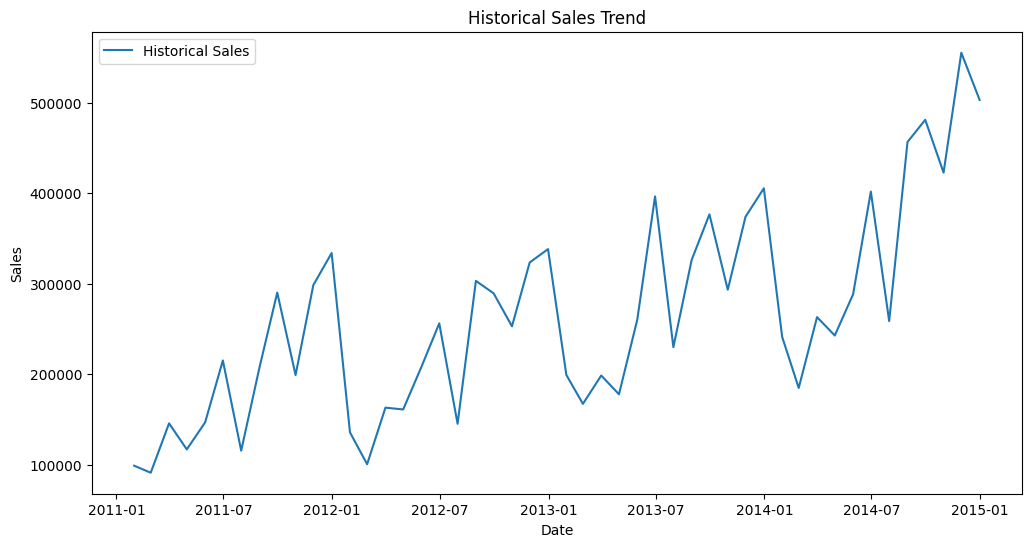

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    label="Historical Sales"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.title("Historical Sales Trend")

plt.legend()

plt.show()

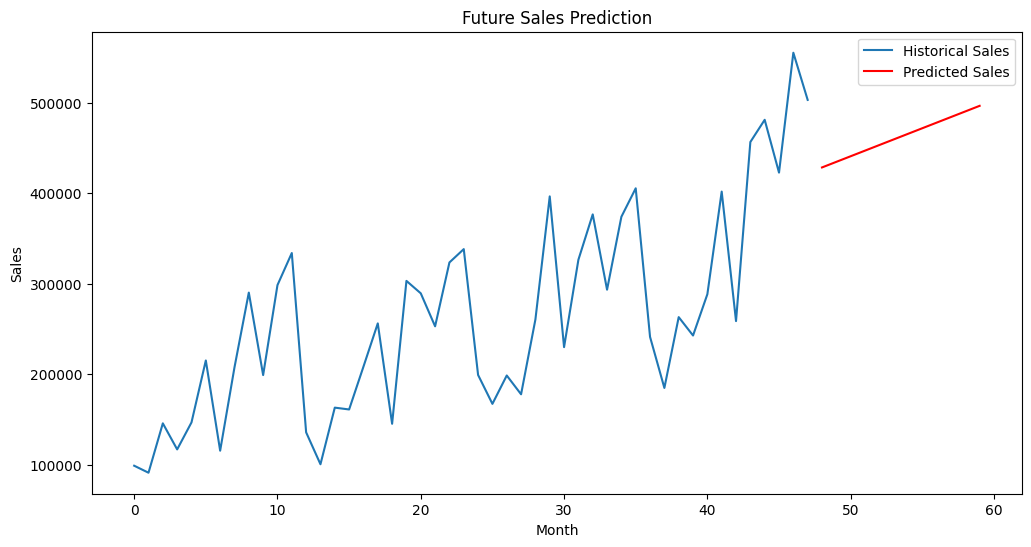

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    label="Historical Sales"
)

plt.plot(
    future["Month"],
    future["Predicted Sales"],
    color="red",
    label="Predicted Sales"
)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.title("Future Sales Prediction")

plt.legend()

plt.show()

In [17]:
future.to_csv("Future_Sales_Prediction.csv",index=False)

In [18]:
from google.colab import files

files.download("Future_Sales_Prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>